In [1]:
import h5py
import torch
from torch.utils.data import Dataset
import numpy as np

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from tqdm import tqdm

In [2]:
class BaselineDataset(Dataset):
    def __init__(self, dataset_path, preprocessing, mode):
        super(BaselineDataset, self).__init__()
        self.dataset_path = dataset_path
        self.preprocessing = preprocessing
        self.mode = mode
        
        with h5py.File(self.dataset_path, 'r') as hdf:        
            self.image_ids = list(hdf.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        with h5py.File(self.dataset_path, 'r') as hdf:
            img = torch.tensor(hdf.get(img_id).get('img'))
            label = np.array(hdf.get(img_id).get('label')) if self.mode == 'train' else None
        return self.preprocessing(img).float(), label

In [3]:
def compute_average_histogram(images, bins=256):
    hist_accum = np.zeros((3, bins))  # Pour chaque canal (R, G, B)
    num_images = len(images)

    for img in images:
        img = np.swapaxes(img, 0, 2)
        img = (img * 255).astype(np.uint8)
        for i in range(3):  # Canaux R, G, B
            hist = cv2.calcHist([img], [i], None, [bins], [0, 256])
            hist /= hist.sum()  # Normalisation
            hist_accum[i] += hist.flatten()
    
    return hist_accum / num_images   # Moyenne des histogrammes


def match_histogram(image, reference_hist, bins=256):
    im = (image.T * 255).astype(np.uint8)
    matched = im.copy()
    for i in range(3):  # Canaux R, G, B
        orig_hist = cv2.calcHist([im], [i], None, [bins], [0, 256])
        orig_hist /= orig_hist.sum()

        cdf_orig = np.cumsum(orig_hist)  # CDF de l'image d'entrée
        cdf_ref = np.cumsum(reference_hist[i])  # CDF de la référence

        lookup_table = np.interp(cdf_orig, cdf_ref, np.arange(bins))
        matched[:, :, i] = cv2.LUT(im[:, :, i], lookup_table.astype(np.uint8))

    return matched.T / 255

In [4]:
mean_hists_list = []
for path in tqdm(os.listdir("data/train/")):
    dataset = BaselineDataset("data/train/" + path, lambda x: x , "train")
    images = [np.array(d[0]) for d in dataset]
    mean_hists_list.append(compute_average_histogram(images))

  0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\Chardin Pierre\AppData\Local\Temp\ipykernel_16844\1650232611.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  img = torch.tensor(hdf.get(img_id).get('img'))
100%|██████████| 1000/1000 [19:03<00:00,  1.14s/it]


In [5]:
mean_hists = np.mean(np.array(mean_hists_list), axis = 0)

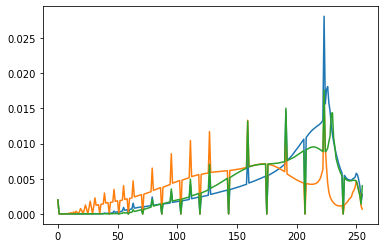

In [6]:
plt.plot(mean_hists[0])
plt.plot(mean_hists[1])
plt.plot(mean_hists[2])

In [13]:
for file in tqdm(os.listdir("data/train/")):
    input_file = "data/train/" + file
    output_file = "data/matched_hist/train/" + file
    with h5py.File(input_file, "r") as f:
        with h5py.File(output_file, "w") as out_f:
            indices = list(f.keys())  # Liste des indices des images
            for idx in indices:
                img = f[idx]["img"][:]
                new_img = match_histogram(img, mean_hists)
                group = out_f.create_group(idx)
                group.create_dataset("img", data=new_img)  # Nouvelle image
                group.create_dataset("label", data=f[idx]["label"][()])  # Copier le label
                group.create_dataset("metadata", data=f[idx]["metadata"][()])  # Copier les métadonnées

100%|██████████| 1000/1000 [08:41<00:00,  1.92it/s]


In [3]:
batch_size = 5  # Nombre de fichiers par commit
counter = 0
files_to_add = []

# Lister tous les fichiers .h5 dans train, test et val*
root = "data/matched_hist/train/"
for file in os.listdir(root):
    if file.endswith(".h5"):
        files_to_add.append(os.path.join(root, file))

root = "data/matched_hist/test/"
for file in os.listdir(root):
    if file.endswith(".h5"):
        files_to_add.append(os.path.join(root, file))

In [4]:
import subprocess
# Découper la liste en paquets et pousser en plusieurs fois
for i in tqdm(range(0, len(files_to_add), batch_size)):
    batch = files_to_add[i : i + batch_size]

    # Ajouter les fichiers au commit
    subprocess.run(["git", "add"] + batch)
    subprocess.run(["git", "commit", "-m", f"Ajout de {len(batch)} fichiers"])
    subprocess.run(["git", "push", "origin", "Pierre"])  # Remplace "main" si besoin

100%|██████████| 400/400 [8:42:24<00:00, 78.36s/it]      
